# Condensed Matter: Quantum Kernel Phase Discovery

Use quantum kernel PCA, quantum kernel classification, and quantum one-class detection to separate finite-size TFIM phases from correlation features.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Identify ferromagnetic and paramagnetic regimes from compact observables.

**Explicit variables.** `h_values` define sampled fields, `y` stores phase labels, `z_train` is the quantum-kernel PCA representation, and `phase_anomaly_label` comes from one-class detection.

**Quantum advantage context.** Fidelity kernels can expose nonlinear geometry in correlated features. This is a benchmarkable example, not an advantage proof.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

A local exact-diagonalization simulator builds four-site TFIM observables for fields below and above the finite-size transition region.

In [2]:
def tfim_features_for_phase(h_values, *, n_sites=4, noise=0.015, seed=401):
    return tfim_ground_observables(h_values, n_sites=n_sites, noise=noise, seed=seed)

# Reuse the same compact exact-diagonalization utilities, kept local to the notebook.
def kron_all(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out

I = np.eye(2)
X = np.array([[0.0, 1.0], [1.0, 0.0]])
Z = np.array([[1.0, 0.0], [0.0, -1.0]])

def op_on(n_sites, site, op):
    ops = [I] * n_sites
    ops[site] = op
    return kron_all(ops)

def two_site_op(n_sites, i, j, op_i, op_j):
    ops = [I] * n_sites
    ops[i] = op_i
    ops[j] = op_j
    return kron_all(ops)

def tfim_ground_observables(h_values, *, n_sites=4, noise=0.015, seed=401):
    rng = np.random.default_rng(seed)
    z_ops = [op_on(n_sites, i, Z) for i in range(n_sites)]
    x_ops = [op_on(n_sites, i, X) for i in range(n_sites)]
    zz_ops = [two_site_op(n_sites, i, (i + 1) % n_sites, Z, Z) for i in range(n_sites)]
    rows = []
    for h in h_values:
        H = np.zeros((2**n_sites, 2**n_sites))
        for zz in zz_ops:
            H -= zz
        for xop in x_ops:
            H -= h * xop
        eigvals, eigvecs = np.linalg.eigh(H)
        psi = eigvecs[:, np.argmin(eigvals)]
        rows.append([
            np.mean([np.vdot(psi, z @ psi).real for z in z_ops]),
            np.mean([np.vdot(psi, x @ psi).real for x in x_ops]),
            np.mean([np.vdot(psi, zz @ psi).real for zz in zz_ops]),
            eigvals.min() / n_sites,
        ])
    rows = np.asarray(rows, dtype=float)
    return rows + rng.normal(0.0, noise, size=rows.shape)

rng = np.random.default_rng(401)
ferro_h = rng.uniform(0.25, 0.8, size=18)
para_h = rng.uniform(1.25, 1.9, size=18)
h_values = np.concatenate([ferro_h, para_h])
y = np.concatenate([np.zeros_like(ferro_h, dtype=int), np.ones_like(para_h, dtype=int)])
features = tfim_ground_observables(h_values, noise=0.012, seed=401)

x_train, x_test, y_train, y_test, h_train, h_test = train_test_split(
    features, y, h_values, test_size=0.3, random_state=401, stratify=y
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Problem", "TFIM phase discovery/classification"),
        ("Samples", int(len(y))),
        ("Classes", {0: "ferromagnetic", 1: "paramagnetic"}),
        ("Features", ["<Z>", "<X>", "<ZZ>", "E0/N"]),
    ],
)


Dataset
+----------+-----------------------------------------+
| Metric   | Value                                   |
+----------+-----------------------------------------+
| Problem  | TFIM phase discovery/classification     |
| Samples  | 36                                      |
| Classes  | {0: 'ferromagnetic', 1: 'paramagnetic'} |
| Features | [<Z>, <X>, <ZZ>, E0/N]                  |
+----------+-----------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

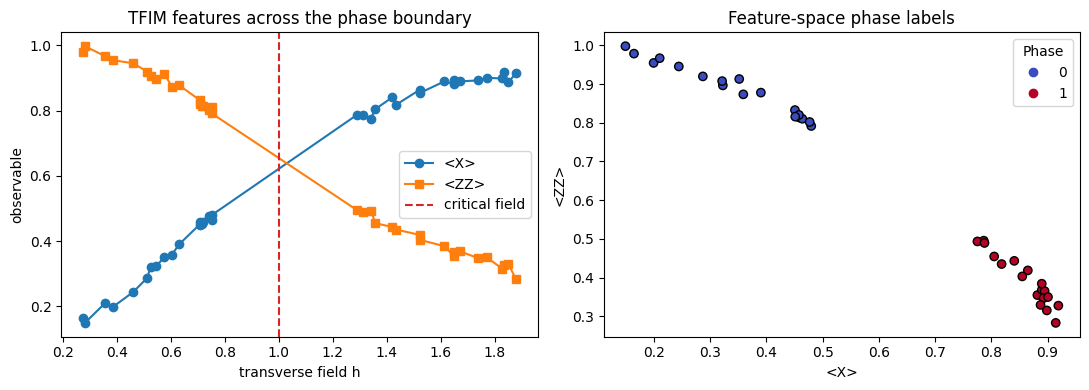

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = np.argsort(h_values)
axes[0].plot(h_values[order], features[order, 1], "o-", label="<X>")
axes[0].plot(h_values[order], features[order, 2], "s-", label="<ZZ>")
axes[0].axvline(1.0, linestyle="--", color="tab:red", label="critical field")
axes[0].set_title("TFIM features across the phase boundary")
axes[0].set_xlabel("transverse field h")
axes[0].set_ylabel("observable")
axes[0].legend()
scatter = axes[1].scatter(features[:, 1], features[:, 2], c=y, cmap="coolwarm", edgecolor="black")
axes[1].set_title("Feature-space phase labels")
axes[1].set_xlabel("<X>")
axes[1].set_ylabel("<ZZ>")
axes[1].legend(*scatter.legend_elements(), title="Phase")
plt.tight_layout()
plt.show()


## Package-client quantum phase models

In [4]:
kernel = QuantumKernel(embedding="zz", seed=401)
kpca = QuantumKernelPCA(kernel, n_components=2)
z_train = kpca.fit_transform(x_train)
z_test = kpca.transform(x_test)

clf = QuantumKernelClassifier(QuantumKernel(embedding="zz", seed=402), c=2.0)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

normal_train = x_train[y_train == 0]
one_class = QuantumOneClassClassifier(QuantumKernel(embedding="zz", seed=403), nu=0.2)
one_class.fit(normal_train)
anomaly_pred = one_class.predict(x_test)
# Training on ferromagnetic samples only: -1 means not ferromagnetic-like.
phase_anomaly_label = (anomaly_pred == -1).astype(int)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)
base_pred = logreg.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, y_pred),
    "one_class_phase_accuracy": accuracy_score(y_test, phase_anomaly_label),
    "logistic_accuracy": accuracy_score(y_test, base_pred),
    "kpca_eigenvalues": kpca.eigenvalues_.tolist(),
}

print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("One-class phase accuracy", results["one_class_phase_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
        ("Kernel PCA eigenvalues", results["kpca_eigenvalues"]),
    ],
)


Results
+--------------------------+--------------------+
| Metric                   | Value              |
+--------------------------+--------------------+
| Quantum kernel accuracy  | 1                  |
| One-class phase accuracy | 0.727273           |
| Logistic accuracy        | 1                  |
| Kernel PCA eigenvalues   | [4.69121, 3.03512] |
+--------------------------+--------------------+



## Plots

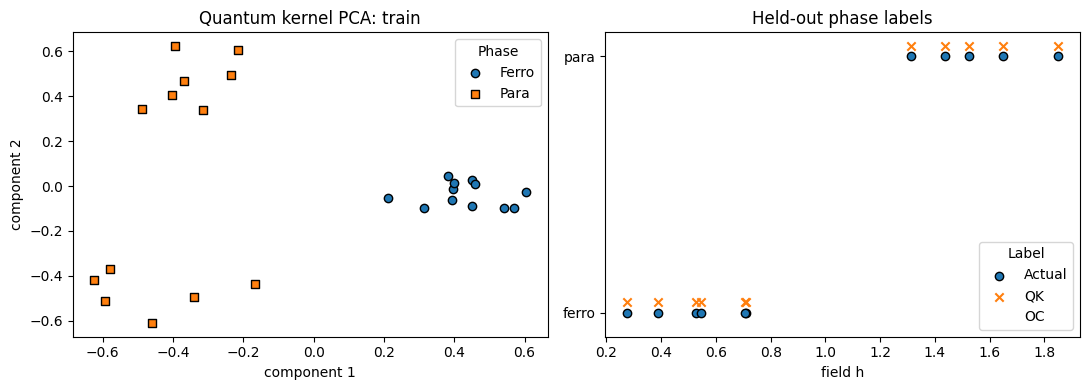

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for cls, name, marker in [(0, "Ferro", "o"), (1, "Para", "s")]:
    mask = y_train == cls
    axes[0].scatter(
        z_train[mask, 0],
        z_train[mask, 1],
        marker=marker,
        label=name,
        edgecolor="black",
    )
axes[0].set_title("Quantum kernel PCA: train")
axes[0].set_xlabel("component 1")
axes[0].set_ylabel("component 2")
axes[0].legend(title="Phase")

axes[1].scatter(h_test, y_test, label="Actual", edgecolor="black")
axes[1].scatter(h_test, y_pred + 0.04, marker="x", label="QK")
axes[1].scatter(h_test, phase_anomaly_label - 0.04, marker="s", facecolors="none", label="OC")
axes[1].set_title("Held-out phase labels")
axes[1].set_xlabel("field h")
axes[1].set_yticks([0, 1], ["ferro", "para"])
axes[1].legend(title="Label")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "tfim_phase_discovery",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"h": float(h), "actual": int(a), "kernel": int(p), "one_class": int(o)}
        for h, a, p, o in zip(h_test[:8], y_test[:8], y_pred[:8], phase_anomaly_label[:8])
    ],
    "passed": bool(
        results["quantum_kernel_accuracy"] >= 0.7
        and np.isfinite(z_train).all()
        and set(anomaly_pred).issubset({-1, 1})
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+----------------------+
| Metric        | Value                |
+---------------+----------------------+
| problem       | tfim_phase_discovery |
| n_train       | 25                   |
| n_test        | 11                   |
| feature_count | 4                    |
+---------------+----------------------+

Results
+--------------------------+--------------------+
| Metric                   | Value              |
+--------------------------+--------------------+
| quantum_kernel_accuracy  | 1                  |
| one_class_phase_accuracy | 0.727273           |
| logistic_accuracy        | 1                  |
| kpca_eigenvalues         | [4.69121, 3.03512] |
+--------------------------+--------------------+

Sample predictions
+----------+--------+--------+-----------+
| h        | actual | kernel | one_class |
+----------+--------+--------+-----------+
| 0.709562 | 0      | 0      | 0         |
| 0.525813 | 0      | 0      | 0         |
| 0.38780